# Лабоораторная работа 4

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


In [26]:
cover_dir = Path('BOWS2') / 'cover'

image_paths = sorted(cover_dir.glob('*.pgm'), key=lambda p: int(p.stem))

images = [np.array(Image.open(path), dtype=np.uint8) for path in image_paths]
images = np.stack(images, axis=0)

print(f'Loaded images: {images.shape[0]}')
print(f'Image size: {images.shape[1:]}')

Loaded images: 2000
Image size: (256, 256)


### 1. Расчет вектора признаков

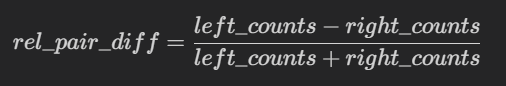

- это главный PoV-признак: перекос внутри пары.
- при встраивании (LSB-подобном) перекос обычно уменьшается (значения в паре «выравниваются»).
- поэтому этот вектор помогает классификатору отличать чистые и модифицированные изображения.

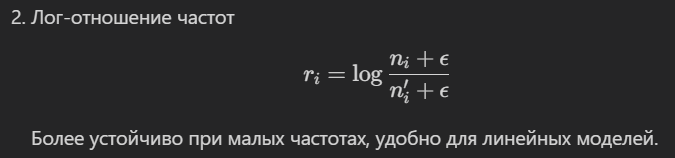

In [ ]:
def pair_value_feature_vector(image: np.ndarray, p: int = 2) -> np.ndarray:
    if not (1 <= p <= 8):
        raise ValueError('p must be in [1, 8] for uint8 images')

    image_u8 = image.astype(np.uint8, copy=False)
    hist = np.bincount(image_u8.ravel(), minlength=256).astype(np.float64)

    mask = 1 << (p - 1) # получаем маску для выбранной битовой плоскости
    left = np.arange(256, dtype=np.uint16) # Для каждого значения x находится парное x', отличающееся только битом p
    right = left ^ mask

    # Убираем дубли пар
    pair_selector = left < right
    left = left[pair_selector]
    right = right[pair_selector]
    
    # берем частоты из гистограмм
    left_counts = hist[left]
    right_counts = hist[right]
    pair_counts = left_counts + right_counts

    # # вариант 1 нормированная разница частот
    # rel_pair_diff = np.divide(
    #     left_counts - right_counts,
    #     pair_counts,
    #     out=np.zeros_like(pair_counts),
    #     where=pair_counts > 0,
    # )

    
    # второй вариант
    eps = 1.0
    rel_pair_diff = np.log((left_counts + eps) / (right_counts + eps))
    
    
    total = pair_counts.sum()
    pair_weight = pair_counts / total if total > 0 else np.zeros_like(pair_counts)
    
    # результат: сначала вектор отклонений, пототм вектор весов
    return np.concatenate([rel_pair_diff, pair_weight], axis=0)

In [28]:
BIT_PLANE = 2
X_features = np.vstack([pair_value_feature_vector(img, p=BIT_PLANE) for img in images])

print(f'Bit-plane p: {BIT_PLANE}')
print(f'Feature matrix shape: {X_features.shape}')
print(f'Features per image: {X_features.shape[1]}')
print('First 10 features of the first image:')
print(np.round(X_features[0, :10], 6))

Bit-plane p: 2
Feature matrix shape: (2000, 256)
Features per image: 256
First 10 features of the first image:
[ 0.        0.        0.       -1.609438 -0.693147 -0.875469 -0.253314
 -0.580407 -0.496102 -0.361185]


### 2. Имитация стеганографической системы

In [29]:
def simulate_lsb_replacement(images: np.ndarray, p: int, 
                             q: float, seed: int = 42) -> tuple[np.ndarray, np.ndarray]:
    if not (1 <= p <= 8):
        raise ValueError("p must be in [1, 8] for uint8 images")
    if not (0.0 <= q <= 1.0):
        raise ValueError("q must be in [0, 1]")

    n_images, h, w = images.shape
    K = int(n_images)

    half = K // 2
    n_pixels = h * w
    m = int(np.floor(q * n_pixels))

    images_sim = images[:K].copy()
    y = np.zeros(K, dtype=np.uint8)
    y[:half] = 1

    if m == 0 or half == 0:
        return images_sim, y

    mask = np.uint8(1 << (p - 1))
    inv_mask = np.uint8(255 ^ mask)
    rng = np.random.default_rng(seed)

    idx = np.arange(m, dtype=np.int64)
    noise = rng.integers(0, 2, size=(half, m), dtype=np.uint8)
    for i in range(half):
        flat = images_sim[i].reshape(-1)
        flat[idx] = (flat[idx] & inv_mask) | (noise[i] * mask)

    return images_sim, y

In [30]:
BIT_PLANE = 2

Q_FILL = 0.5
K_IMAGES = images.shape[0]

images_sim, y = simulate_lsb_replacement(
    images=images,
    p=BIT_PLANE,
    q=Q_FILL,
    seed=42
)

print(f"p = {BIT_PLANE}, q = {Q_FILL}, K = {K_IMAGES}")
print(f"Simulated set shape: {images_sim.shape}")
print(f"Embedded images: {int(y.sum())}, clean images: {int((y == 0).sum())}")

p = 2, q = 0.5, K = 2000
Simulated set shape: (2000, 256, 256)
Embedded images: 1000, clean images: 1000


### 3-4. Подготовка и обучение классификатора, проверка его качества

In [31]:
X_features_sim = np.vstack([pair_value_feature_vector(img, p=BIT_PLANE) for img in images_sim])

rng = np.random.default_rng(42)
embedded_idx = rng.permutation(np.where(y == 1)[0])     
clean_idx = rng.permutation(np.where(y == 0)[0])        

n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
n_train_clean = int(np.floor(0.7 * len(clean_idx)))

train_idx = np.concatenate([
    embedded_idx[:n_train_embedded],
    clean_idx[:n_train_clean],
])
test_idx = np.concatenate([
    embedded_idx[n_train_embedded:],
    clean_idx[n_train_clean:],
])

X_train = X_features_sim[train_idx]
y_train = y[train_idx]
X_test = X_features_sim[test_idx]
y_test = y[test_idx]

print(f'Feature matrix shape: {X_features_sim.shape}')
print(f'Embedded samples: {len(embedded_idx)}, clean samples: {len(clean_idx)}')
print(f'Train size: {len(train_idx)} (embedded={n_train_embedded}, clean={n_train_clean})')
print(f'Test size: {len(test_idx)}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Feature matrix shape: (2000, 256)
Embedded samples: 1000, clean samples: 1000
Train size: 1400 (embedded=700, clean=700)
Test size: 600
X_train: (1400, 256), X_test: (600, 256)


Accuracy: 0.716667
F1-score: 0.715719
Confusion matrix (rows=true, cols=pred):
[[216  84]
 [ 86 214]]


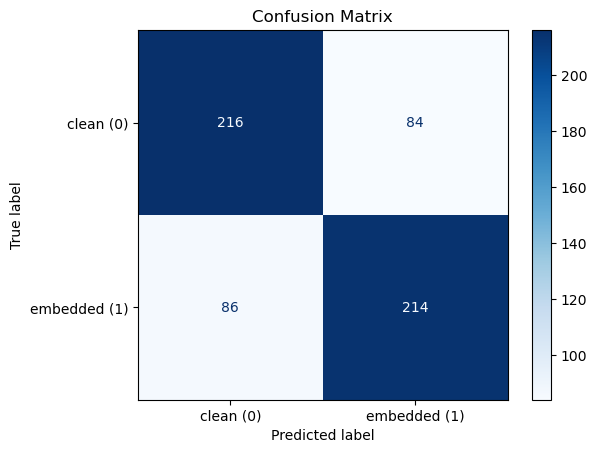

In [32]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {acc:.6f}')
print(f'F1-score: {f1:.6f}')
print('Confusion matrix (rows=true, cols=pred):')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['clean (0)', 'embedded (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

### 5. Исследование параметров для q = 0.1..1.0

  q  accuracy  f1_score
0.1  0.651667  0.643952
0.2  0.648333  0.644182
0.3  0.665000  0.664441
0.4  0.655000  0.650927
0.5  0.716667  0.715719
0.6  0.726667  0.721088
0.7  0.781667  0.779832
0.8  0.806667  0.803390
0.9  0.841667  0.839255
1.0  0.915000  0.915141


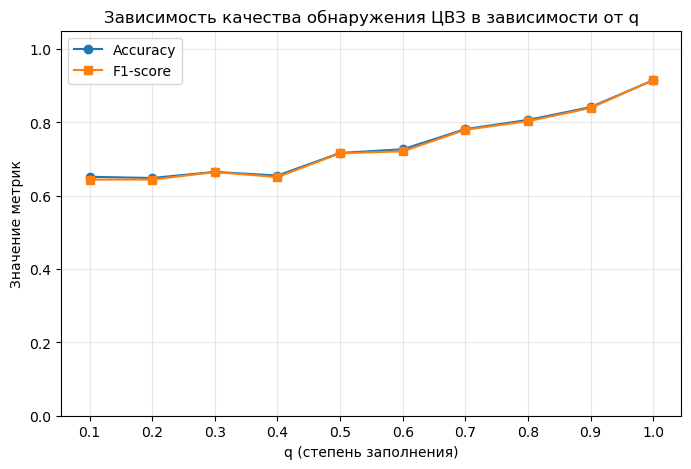

In [33]:
Q_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)

results = []

for q in Q_VALUES:
    images_sim_q, y_q = simulate_lsb_replacement(
        images=images,
        p=BIT_PLANE,
        q=float(q),
        seed=42,
    )

    X_q = np.vstack([pair_value_feature_vector(img, p=BIT_PLANE) for img in images_sim_q])
    
    rng = np.random.default_rng(42)
    embedded_idx = rng.permutation(np.where(y_q == 1)[0])
    clean_idx = rng.permutation(np.where(y_q == 0)[0])   

    n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
    n_train_clean = int(np.floor(0.7 * len(clean_idx)))

    train_idx = np.concatenate([
        embedded_idx[:n_train_embedded],
        clean_idx[:n_train_clean],
    ])
    test_idx = np.concatenate([
        embedded_idx[n_train_embedded:],
        clean_idx[n_train_clean:],
    ])

    X_train_q = X_q[train_idx]
    y_train_q = y_q[train_idx]
    X_test_q = X_q[test_idx]
    y_test_q = y_q[test_idx]

    clf_q = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42)),
    ])
    clf_q.fit(X_train_q, y_train_q)
    y_pred_q = clf_q.predict(X_test_q)

    acc_q = accuracy_score(y_test_q, y_pred_q)
    f1_q = f1_score(y_test_q, y_pred_q)

    results.append({
        'q': float(q),
        'accuracy': float(acc_q),
        'f1_score': float(f1_q),
    })

results_df = pd.DataFrame(results).sort_values('q').reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(results_df['q'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['q'], results_df['f1_score'], marker='s', label='F1-score')
plt.xticks(Q_VALUES)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.xlabel('q (степень заполнения)')
plt.ylabel('Значение метрик')
plt.title('Зависимость качества обнаружения ЦВЗ в зависимости от q')
plt.legend()
plt.show()

### Дополнительное исследование

Выполнить сравнительное исследование не менее 5 разных моде-лей классификаторов для решения поставленной задачи стегоана-лиза. Гиперпараметры выбирать логичным образом.

In [34]:
def pairvalue_score(X: np.ndarray) -> np.ndarray:
    n_pairs = X.shape[1] // 2
    rel_diff = X[:, :n_pairs]
    pair_weight = X[:, n_pairs:2 * n_pairs]
    return np.sum(np.abs(rel_diff) * pair_weight, axis=1)


def fit_pairvalue_threshold(X: np.ndarray, y: np.ndarray) -> float:
    scores = pairvalue_score(X)
    candidates = np.unique(scores)
    if candidates.size == 1:
        return float(candidates[0])

    best_f1 = -1.0
    best_thr = float(candidates[0])
    for thr in candidates:
        y_pred = (scores <= thr).astype(np.uint8)
        f1 = f1_score(y, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_thr


def predict_pairvalue_threshold(X: np.ndarray, threshold: float) -> np.ndarray:
    return (pairvalue_score(X) <= threshold).astype(np.uint8)

In [35]:
def build_models():
    return {
        'LogisticRegression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(C=1.0, max_iter=3000, random_state=42)),
        ]),
        'LinearSVC': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LinearSVC(C=1.0, random_state=42, max_iter=5000)),
        ]),
        'RandomForestClassifier': RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1,
        ),
        'KNeighborsClassifier': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=9, weights='distance', metric='minkowski')),
        ]),
        'GaussianNB': GaussianNB(),
        'MLPClassifier': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation='relu',
                solver='adam',
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=42,
            )),
        ]),
    }

q =  0.1
q =  0.2
q =  0.3
q =  0.4
q =  0.5
q =  0.6
q =  0.7
q =  0.8
q =  0.9
q =  1.0
                 model   q  accuracy  f1_score
            GaussianNB 0.1  0.656667  0.662295
            GaussianNB 0.2  0.666667  0.675325
            GaussianNB 0.3  0.678333  0.691200
            GaussianNB 0.4  0.691667  0.708661
            GaussianNB 0.5  0.706667  0.722397
            GaussianNB 0.6  0.716667  0.732704
            GaussianNB 0.7  0.720000  0.735016
            GaussianNB 0.8  0.748333  0.760697
            GaussianNB 0.9  0.780000  0.786408
            GaussianNB 1.0  0.868333  0.867227
  KNeighborsClassifier 0.1  0.596667  0.553506
  KNeighborsClassifier 0.2  0.621667  0.596803
  KNeighborsClassifier 0.3  0.615000  0.603774
  KNeighborsClassifier 0.4  0.651667  0.647555
  KNeighborsClassifier 0.5  0.658333  0.673046
  KNeighborsClassifier 0.6  0.681667  0.709285
  KNeighborsClassifier 0.7  0.713333  0.750725
  KNeighborsClassifier 0.8  0.746667  0.777778
  KNeighborsClass

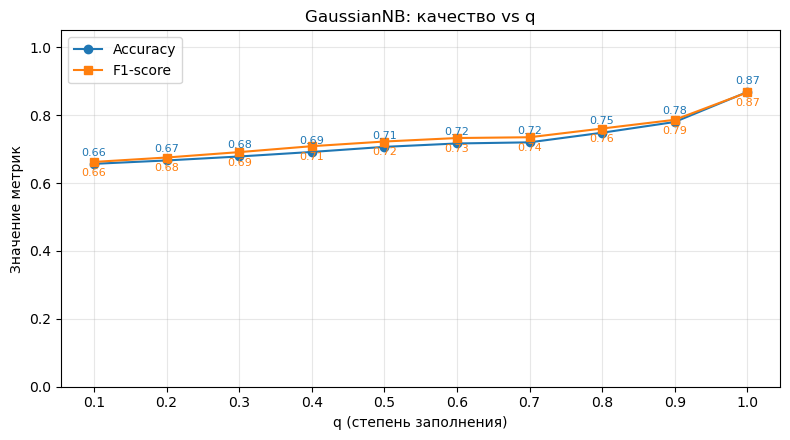

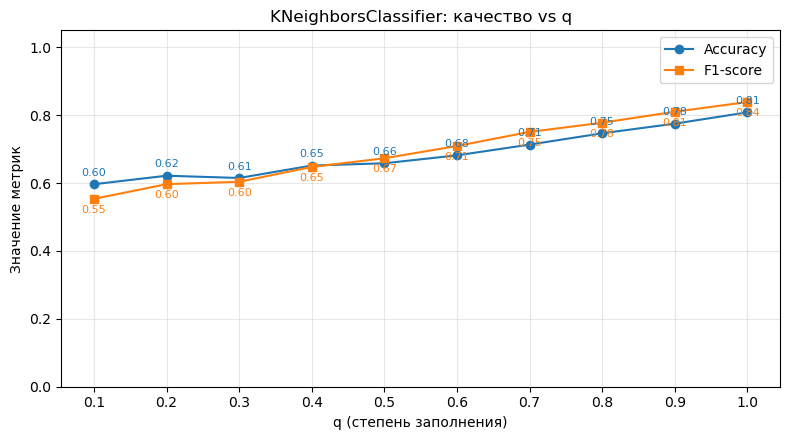

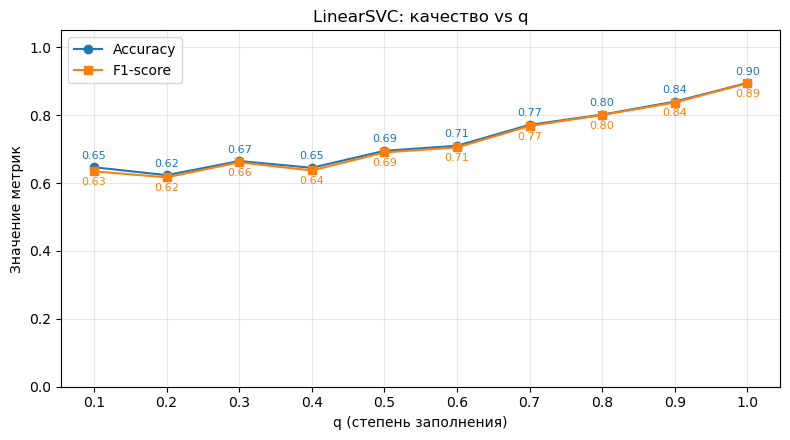

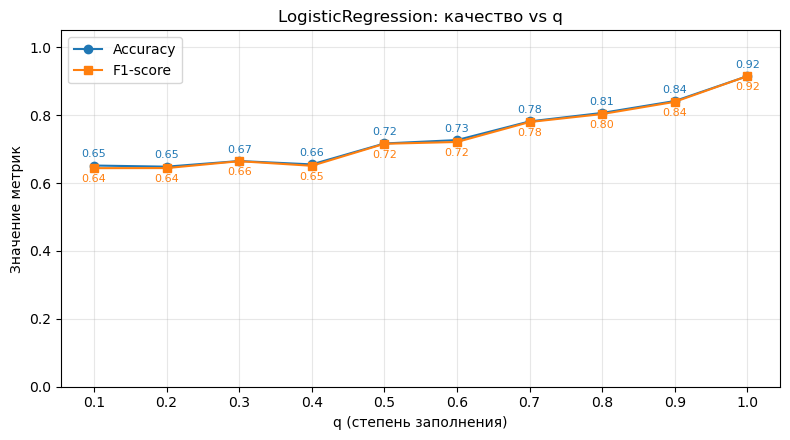

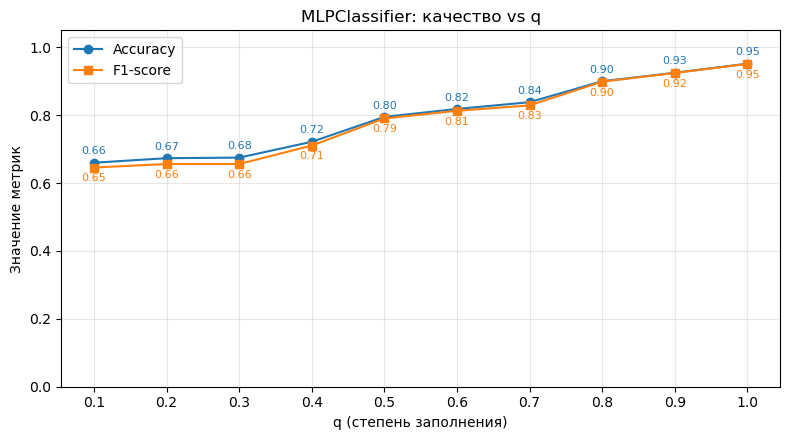

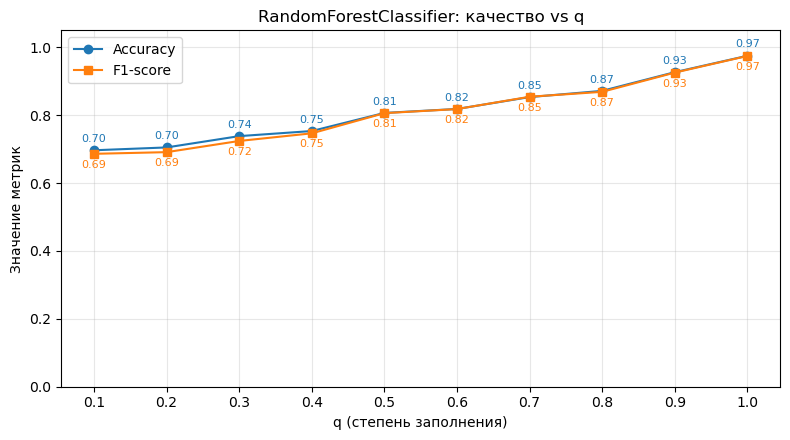

In [36]:
rows = []
for q in Q_VALUES:
    print('q = ', q)
    images_sim_q, y_q = simulate_lsb_replacement(
        images=images,
        p=BIT_PLANE,
        q=float(q),
        seed=42,
    )

    X_q = np.vstack([pair_value_feature_vector(img, p=BIT_PLANE) for img in images_sim_q])

    rng = np.random.default_rng(42)
    embedded_idx = rng.permutation(np.where(y_q == 1)[0])
    clean_idx = rng.permutation(np.where(y_q == 0)[0])

    n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
    n_train_clean = int(np.floor(0.7 * len(clean_idx)))

    train_idx = np.concatenate([
        embedded_idx[:n_train_embedded],
        clean_idx[:n_train_clean],
    ])
    test_idx = np.concatenate([
        embedded_idx[n_train_embedded:],
        clean_idx[n_train_clean:],
    ])

    X_train_q = X_q[train_idx]
    y_train_q = y_q[train_idx]
    X_test_q = X_q[test_idx]
    y_test_q = y_q[test_idx]

    for model_name, clf in build_models().items():
        clf.fit(X_train_q, y_train_q)

        y_pred_q = clf.predict(X_test_q)
        acc_q = accuracy_score(y_test_q, y_pred_q)
        f1_q = f1_score(y_test_q, y_pred_q)

        rows.append({
            'model': model_name,
            'q': float(q),
            'accuracy': float(acc_q),
            'f1_score': float(f1_q)
        })

comparison_by_q_df = pd.DataFrame(rows).sort_values(['model', 'q']).reset_index(drop=True)
print(comparison_by_q_df.to_string(index=False))

for model_name in comparison_by_q_df['model'].unique():
    part = comparison_by_q_df[comparison_by_q_df['model'] == model_name].sort_values('q')
    q_vals = part['q'].to_numpy()
    acc_vals = part['accuracy'].to_numpy()
    f1_vals = part['f1_score'].to_numpy()

    plt.figure(figsize=(8, 4.5))
    line_acc, = plt.plot(q_vals, acc_vals, marker='o', label='Accuracy')
    line_f1, = plt.plot(q_vals, f1_vals, marker='s', label='F1-score')

    acc_color = line_acc.get_color()
    f1_color = line_f1.get_color()

    for x, y in zip(q_vals, acc_vals):
        plt.annotate(
            f'{y:.2f}',
            xy=(x, y),
            xytext=(0, 6),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=acc_color,
        )

    for x, y in zip(q_vals, f1_vals):
        plt.annotate(
            f'{y:.2f}',
            xy=(x, y),
            xytext=(0, -10),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=f1_color,
        )

    plt.xticks(Q_VALUES)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.xlabel('q (степень заполнения)')
    plt.ylabel('Значение метрик')
    plt.title(f'{model_name}: качество vs q')
    plt.legend()
    plt.tight_layout()
    plt.show()

